In [1]:
import numpy as np

In [2]:
!mamba install matplotlib

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 2.098 seconds
  Name  Version  Build         Channel
--------------------------------------------
- pip   26.1.2   pyh145f28c_0  conda-forge


In [3]:
!mamba install scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.347 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.5.1      pyhd8ed1ab_0         conda-forge
+ idna                3.19       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ narwhals            2.25.0     pyhcf101f3_0         conda-forge
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ requests            2.34.2     pyhcf101f3_0         conda-forge
+ scikit-learn        1.9.0      np23py313hb9816c2_0  emscripten-forge-4x
+ setuptools          84.0.0

In [4]:
import matplotlib.pyplot as plt

In [5]:
!mamba install pandas
import pandas as pd

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, scikit-learn, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.913 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.5    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge


In [6]:
data_set=pd.read_csv("date_fruit.csv",skiprows=1,header=None)

data_set

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,422163,2378.9080,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.1440,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.3940,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.2100,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.3540,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,255403,1925.3650,691.8453,477.1796,0.7241,570.2536,0.9785,261028,0.7269,1.4499,...,2.2423,2.3704,2.7202,-25296416768,-19168882688,-18473392128,49.0869,43.0422,42.4153,SOGAY
894,365924,2664.8230,855.4633,551.5447,0.7644,682.5752,0.9466,386566,0.6695,1.5510,...,3.4109,3.5805,3.9910,-31605219328,-21945366528,-19277905920,46.8086,39.1046,36.5502,SOGAY
895,254330,1926.7360,747.4943,435.6219,0.8126,569.0545,0.9925,256255,0.7240,1.7159,...,2.2759,2.5090,2.6951,-22242772992,-19594921984,-17592152064,44.1325,40.7986,40.9769,SOGAY
896,238955,1906.2679,716.6485,441.8297,0.7873,551.5859,0.9604,248795,0.6954,1.6220,...,2.6769,2.6874,2.7991,-26048595968,-21299822592,-19809978368,51.2267,45.7162,45.6260,SOGAY


In [7]:
ds_array=data_set.to_numpy()
X=ds_array[:,:34]
Y=ds_array[:,-1]
Y.shape

(898,)

In [8]:
rng=np.random.default_rng(42)
perm=rng.permutation(X.shape[0])

X,Y=X[perm],Y[perm] 

X=X.astype(np.float64)


In [9]:
X_train=X[:628,:]
X_cv=X[628:667,:]
X_test=X[667:,:]



In [10]:
mu=np.mean(X_train,axis=0)
sigma=np.std(X_train,axis=0)

X_train_normalized=(X_train-mu)/sigma
X_cv_normalized=(X_cv-mu)/sigma
X_test_normalized=(X_test-mu)/sigma



In [11]:
Y_transformed=np.zeros((Y.shape[0],7),dtype=int)

for i in range(Y.shape[0]):
    if Y[i]=="BERHI":
        Y_transformed[i]=[1,0,0,0,0,0,0]
    elif Y[i]=="DEGLET":
        Y_transformed[i]=[0,1,0,0,0,0,0]
    elif Y[i]=="DOKOL":
        Y_transformed[i]=[0,0,1,0,0,0,0]
    elif Y[i]=="IRAQI":
        Y_transformed[i]=[0,0,0,1,0,0,0]
    elif Y[i]=="ROTANA":
        Y_transformed[i]=[0,0,0,0,1,0,0]
    elif Y[i]=="SAFAVI":
        Y_transformed[i]=[0,0,0,0,0,1,0]
    elif Y[i]=="SOGAY":
        Y_transformed[i]=[0,0,0,0,0,0,1]

Y_transformed_train = Y_transformed[:628]
Y_transformed_cv= Y_transformed[628:667]
Y_transformed_test= Y_transformed[667:]
        

In [12]:
def train(iters=1000,lr=0.1):
    W=np.zeros((Y_transformed_train.shape[1],X_train_normalized.shape[1]))
    B=np.zeros((Y_transformed_train.shape[1],1))


    true_class=np.argmax(Y_transformed_train.T,axis=0)
    loss_history = []
    for i in range(iters):
        Z=np.dot(W,X_train_normalized.T)+B
        A=np.exp(Z)/np.sum(np.exp(Z),axis=0,keepdims=True)
        a_j = A[true_class, np.arange(X_train_normalized.shape[0])]
        loss = -np.mean(np.log(a_j))
        loss_history.append(loss)

        dZ = A - Y_transformed_train.T
        dW = (1/X_train_normalized.shape[0]) * np.dot(dZ, X_train_normalized)
        dB = (1/X_train_normalized.shape[0]) * np.sum(dZ, axis=1, keepdims=True)

        W -= lr * dW
        B -= lr * dB
        
    return W,B,loss_history
    
W,B,loss_history=train()

        
        

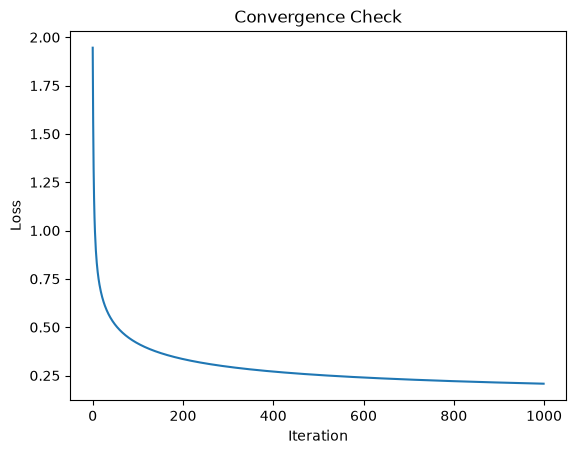

In [13]:
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Convergence Check")
plt.show()



In [14]:
def predict(X, W, B):
    Z = np.dot(W, X.T) + B
    expZ = np.exp(Z)
    A = expZ / np.sum(expZ, axis=0, keepdims=True)
    return np.argmax(A, axis=0)

In [15]:
best_acc = 0
best_params = None


for lr_try in [0.01, 0.05, 0.1, 0.5, 1.0]:
    for iters_try in [500, 1000, 2000]:
        W_try, B_try, _ = train(iters=iters_try, lr=lr_try)
        preds = predict(X_cv_normalized, W_try, B_try)
        cv_true = np.argmax(Y_transformed_cv, axis=1)
        acc = np.mean(preds == cv_true)
        print(f"lr={lr_try}, iters={iters_try} -> cv_acc={acc:.4f}")
        if acc > best_acc:
            best_acc = acc
            best_params = (lr_try, iters_try)

print(f"\nBest: lr={best_params[0]}, iters={best_params[1]}, cv_acc={best_acc:.4f}")

lr=0.01, iters=500 -> cv_acc=0.8205
lr=0.01, iters=1000 -> cv_acc=0.8462
lr=0.01, iters=2000 -> cv_acc=0.8462
lr=0.05, iters=500 -> cv_acc=0.8462
lr=0.05, iters=1000 -> cv_acc=0.8462
lr=0.05, iters=2000 -> cv_acc=0.8462
lr=0.1, iters=500 -> cv_acc=0.8462
lr=0.1, iters=1000 -> cv_acc=0.8462
lr=0.1, iters=2000 -> cv_acc=0.8974
lr=0.5, iters=500 -> cv_acc=0.8974
lr=0.5, iters=1000 -> cv_acc=0.8718
lr=0.5, iters=2000 -> cv_acc=0.8718
lr=1.0, iters=500 -> cv_acc=0.8718
lr=1.0, iters=1000 -> cv_acc=0.8718
lr=1.0, iters=2000 -> cv_acc=0.8718

Best: lr=0.1, iters=2000, cv_acc=0.8974


In [16]:
W, B, loss_history = train(iters=best_params[1], lr=best_params[0])

In [17]:
train_preds = predict(X_train_normalized, W, B)
train_true = np.argmax(Y_transformed_train, axis=1)
train_acc = np.mean(train_preds == train_true)
print(f"Train accuracy: {train_acc:.4f}")

test_preds = predict(X_test_normalized, W, B)
test_true = np.argmax(Y_transformed_test, axis=1)
test_acc = np.mean(test_preds == test_true)
print(f"Final test accuracy: {test_acc:.4f}")

Train accuracy: 0.9522
Final test accuracy: 0.9264


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y_train_1d = np.argmax(Y_transformed_train, axis=1)
y_cv_1d    = np.argmax(Y_transformed_cv, axis=1)
y_test_1d  = np.argmax(Y_transformed_test, axis=1)

sk_model = LogisticRegression(max_iter=2000)
sk_model.fit(X_train_normalized, y_train_1d)

sk_train_acc = accuracy_score(y_train_1d, sk_model.predict(X_train_normalized))
sk_cv_acc    = accuracy_score(y_cv_1d, sk_model.predict(X_cv_normalized))
sk_test_acc  = accuracy_score(y_test_1d, sk_model.predict(X_test_normalized))

print(f"sklearn — train: {sk_train_acc:.4f}, cv: {sk_cv_acc:.4f}, test: {sk_test_acc:.4f}")
print(f"yours   — train: {train_acc:.4f}, cv: {best_acc:.4f}, test: {test_acc:.4f}")

sklearn — train: 0.9602, cv: 0.8718, test: 0.9264
yours   — train: 0.9522, cv: 0.8974, test: 0.9264
